<a href="https://colab.research.google.com/github/AlvinMathew001/AI-ML-Internship/blob/main/day2%20titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [4]:
df=pd.read_csv("/content/titanic uncleaned.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [6]:
df['Age_mean_imputed'] = df['Age'].fillna(df['Age'].mean())
df['Age_median_imputed'] = df['Age'].fillna(df['Age'].median())

In [7]:
df['Cabin_mode_imputed'] = df['Cabin'].fillna(df['Cabin'].mode()[0])

In [8]:
df[['Age','Age_mean_imputed','Age_median_imputed']]

,Age,Age_mean_imputed,Age_median_imputed
0,34.5,34.50000,34.5
1,47.0,47.00000,47.0
2,62.0,62.00000,62.0
3,27.0,27.00000,27.0
4,22.0,22.00000,22.0
...,...,...,...
413,NaN,30.27259,27.0
414,39.0,39.00000,39.0
415,38.5,38.50000,38.5
416,NaN,30.27259,27.0


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
sns.set(style="whitegrid")

/tmp/ipykernel_5913/926315115.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Pclass',y='Age',palette='pastel')


<Axes: xlabel='Pclass', ylabel='Age'>

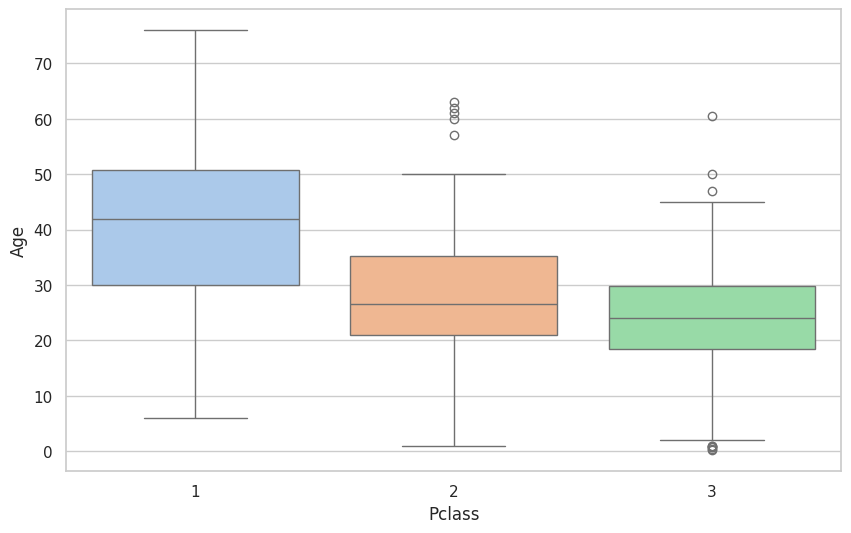

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Pclass',y='Age',palette='pastel')

Text(0, 0.5, 'Age')

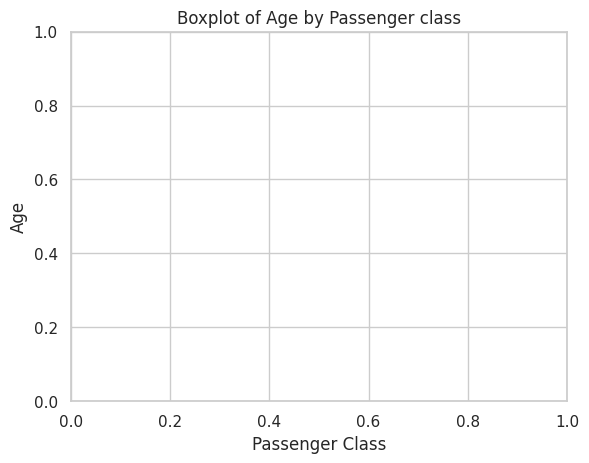

In [12]:
plt.title('Boxplot of Age by Passenger class', fontsize=12)
plt.xlabel('Passenger Class',fontsize=12)
plt.ylabel('Age', fontsize=12)

/tmp/ipykernel_5913/54176827.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Pclass',y='Survived',palette='pastel')


Text(0, 0.5, 'Survived')

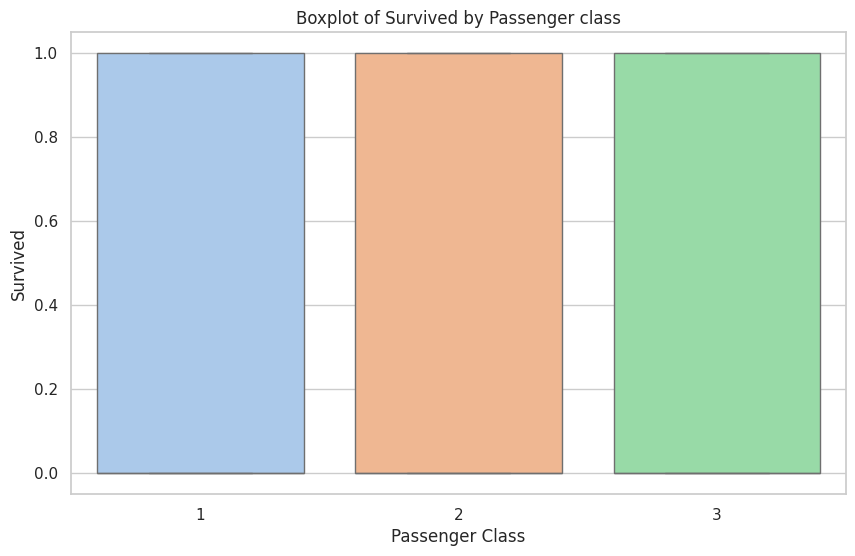

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Pclass',y='Survived',palette='pastel')


plt.title('Boxplot of Survived by Passenger class', fontsize=12)
plt.xlabel('Passenger Class',fontsize=12)
plt.ylabel('Survived', fontsize=12)


In [14]:
from sklearn.preprocessing import LabelEncoder

In [15]:
encoded_data = df.copy()

In [16]:
label_encoder= LabelEncoder()
encoded_data['Sex_Label_Encoded']=label_encoder.fit_transform(encoded_data['Sex'])
one_hot_encoded = pd.get_dummies(encoded_data['Embarked'], prefix='Embarked')
encoded_data = pd.concat([encoded_data, one_hot_encoded], axis=1)

# Since 'Pclass' is ordinal, we can create a mapped column for demonstration.
pclass_mapping = {1: 'First', 2: 'Second', 3: 'Third'}
# 3. Ordinal Encoding For p class
encoded_data['Pclass_Category'] = encoded_data['Pclass'].map(pclass_mapping)

# Display the resulting dataset with relevant encoded columns
print(encoded_data[['Sex', 'Sex_Label_Encoded', 'Embarked', 'Embarked_Q', 'Embarked_S', 'Embarked_C', 'Pclass', 'Pclass_Category']].head())

      Sex  Sex_Label_Encoded Embarked  Embarked_Q  Embarked_S  Embarked_C  \
0    male                  1        Q        True       False       False   
1  female                  0        S       False        True       False   
2    male                  1        Q        True       False       False   
3    male                  1        S       False        True       False   
4  female                  0        S       False        True       False   

   Pclass Pclass_Category  
0       3           Third  
1       3           Third  
2       2          Second  
3       3           Third  
4       3           Third  


In [17]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [18]:
file_path="/content/titanic uncleaned.csv"

In [19]:
titanic_data = pd.read_csv(file_path)


In [20]:
numeric_columns = ['Age', 'Fare', 'Pclass']

In [21]:
titanic_data.dropna(subset=numeric_columns,inplace=True)

In [22]:
minmax_scaler=MinMaxScaler()
standard_scaler=StandardScaler()

In [23]:
titanic_data['Age_MinMax']=minmax_scaler.fit_transform(titanic_data[['Age']])
titanic_data['Fare_MinMax']=minmax_scaler.fit_transform(titanic_data[['Fare']])
titanic_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_MinMax,Fare_MinMax
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0.452723,0.015282
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0.617566,0.013663
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0.815377,0.018909
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0.353818,0.016908
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0.287881,0.023984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,1301,1,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S,0.037320,0.026887
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q,0.485692,0.175668
412,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S,0.367005,0.015176
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0.512066,0.212559


In [24]:
titanic_data['Age_Standard']=minmax_scaler.fit_transform(titanic_data[['Age']])
titanic_data['Fare_Standard']=minmax_scaler.fit_transform(titanic_data[['Fare']])
titanic_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_MinMax,Fare_MinMax,Age_Standard,Fare_Standard
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0.452723,0.015282,0.452723,0.015282
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0.617566,0.013663,0.617566,0.013663
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0.815377,0.018909,0.815377,0.018909
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0.353818,0.016908,0.353818,0.016908
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0.287881,0.023984,0.287881,0.023984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,1301,1,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S,0.037320,0.026887,0.037320,0.026887
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q,0.485692,0.175668,0.485692,0.175668
412,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S,0.367005,0.015176,0.367005,0.015176
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0.512066,0.212559,0.512066,0.212559


In [25]:
titanic_data[['Age','Age_MinMax','Age_Standard']]

,Age,Age_MinMax,Age_Standard
0,34.5,0.452723,0.452723
1,47.0,0.617566,0.617566
2,62.0,0.815377,0.815377
3,27.0,0.353818,0.353818
4,22.0,0.287881,0.287881
...,...,...,...
409,3.0,0.037320,0.037320
411,37.0,0.485692,0.485692
412,28.0,0.367005,0.367005
414,39.0,0.512066,0.512066
